In [1]:
pip install numpy pandas matplotlib seaborn yfinance tweepy transformers datasets scikit-learn torch


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install polygon-api-client

Note: you may need to restart the kernel to use updated packages.


In [6]:
from polygon import RESTClient


API_KEY = "hxGeYKs1qclcdpNgPzniVjNvtgIcbulg"
client = RESTClient(API_KEY)

In [4]:
pip install "keras<3.0.0" praw


Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from transformers import pipeline
from datetime import date
import matplotlib.pyplot as plt
from polygon import RESTClient
from transformers import pipeline, AutoTokenizer
import pandas as pd


In [2]:
df = pd.read_csv('/Users/sahilgulati/Desktop/Stock_Testing_vsc/Stock-testing/nasdaq-listed.csv')
print(df.head())

  Symbol                                      Security Name
0  AACBU                 Artius II Acquisition Inc. - Units
1   AACG  ATA Creativity Global - American Depositary Sh...
2   AADI               Aadi Bioscience, Inc. - Common Stock
3   AADR                AdvisorShares Dorsey Wright ADR ETF
4    AAL       American Airlines Group, Inc. - Common Stock


In [3]:
tickers_nasdaq = df['Symbol'].tolist()
print(tickers_nasdaq[0:10])

['AACBU', 'AACG', 'AADI', 'AADR', 'AAL', 'AAME', 'AAOI', 'AAON', 'AAPB', 'AAPD']


In [4]:
from transformers import pipeline

sentiment_analyser = pipeline("sentiment-analysis",model="distilbert-base-uncased-finetuned-sst-2-english")

Device set to use mps:0


In [5]:
from datetime import date
import praw
import re
from collections import Counter

# Reddit API Setup
reddit = praw.Reddit(
    client_id="_f9G2wmqD_D-8BU7usAkuw",
    client_secret="gLt3IkPt4B-GrPV-yQ44-LUy2XXmnQ",
    user_agent="sahilprostar/1.0"
)

# Load NASDAQ tickers (assuming tickers_nasdaq is already loaded from CSV)
Subreddit = input("Enter the subreddit name (default: WallStreetBets): ") or "wallstreetbets"
subreddit_chosen = reddit.subreddit(Subreddit)
hot_posts = subreddit_chosen.hot(limit=50)

# Extract NASDAQ tickers from Reddit (Titles, Bodies, and Comments)
tickers_reddit = []

for post in hot_posts:
    # Extract tickers from post title
    words_title = re.findall(r'\b[A-Z]{2,5}\b', post.title)
    valid_tickers_title = [word for word in words_title if word in tickers_nasdaq]
    tickers_reddit.extend(valid_tickers_title)

    # Extract tickers from post body (selftext)
    if post.selftext:
        words_body = re.findall(r'\b[A-Z]{2,5}\b', post.selftext)
        valid_tickers_body = [word for word in words_body if word in tickers_nasdaq]
        tickers_reddit.extend(valid_tickers_body)

    # Extract tickers from comments
    post.comments.replace_more(limit=0)  # Load all comments
    for comment in post.comments.list():
        if comment.body:
            words_comment = re.findall(r'\b[A-Z]{2,5}\b', comment.body)
            valid_tickers_comment = [word for word in words_comment if word in tickers_nasdaq]
            tickers_reddit.extend(valid_tickers_comment)

# Count top mentioned stocks
top_stocks = Counter(tickers_reddit).most_common(10)

# Display results
print("\n📅 Date:", date.today())
print("📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):")
for idx, (stock, count) in enumerate(top_stocks, 1):
    print(f"{idx}. {stock} ({count} mentions)")



📅 Date: 2025-03-19
📈📉 Top 10 Mentioned Stocks on Reddit (Titles, Bodies & Comments):
1. TSLA (332 mentions)
2. OP (60 mentions)
3. EU (43 mentions)
4. MSTR (42 mentions)
5. NVDA (27 mentions)
6. TLT (23 mentions)
7. TSLR (14 mentions)
8. GOOG (11 mentions)
9. QQQ (10 mentions)
10. INTC (8 mentions)


Device set to use mps:0



📅 Date: 2025-03-19
📈📉 Top 10 Mentioned Stocks on Reddit with Sentiment Analysis:
1. TSL: Bearish 📉 (51 Positive, 274 Negative)
2. TSLA: Bearish 📉 (48 Positive, 259 Negative)
3. PY: Bearish 📉 (8 Positive, 72 Negative)
4. OP: Bearish 📉 (15 Positive, 58 Negative)
5. TC: Bearish 📉 (5 Positive, 65 Negative)
6. TH: Bearish 📉 (12 Positive, 54 Negative)
7. OM: Bearish 📉 (11 Positive, 48 Negative)
8. ON: Bearish 📉 (7 Positive, 47 Negative)
9. Z: Bearish 📉 (13 Positive, 41 Negative)
10. CA: Bearish 📉 (8 Positive, 34 Negative)


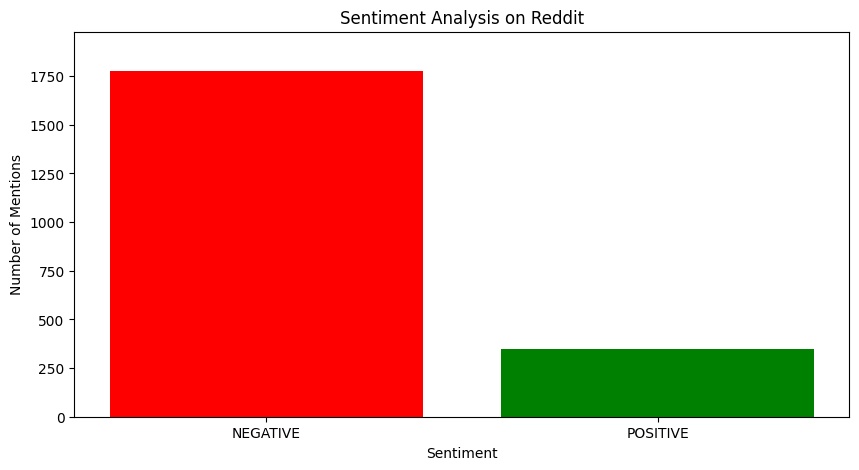

In [6]:
from collections import defaultdict, Counter
import praw
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline, AutoTokenizer
from datetime import date

# Polygon API Setup
API_KEY = "hxGeYKs1qclcdpNgPzniVjNvtgIcbulg"
client = RESTClient(API_KEY)

# Reddit API Setup
reddit = praw.Reddit(
    client_id="_f9G2wmqD_D-8BU7usAkuw",
    client_secret="gLt3IkPt4B-GrPV-yQ44-LUy2XXmnQ",
    user_agent="sahilprostar/1.0"
)

# Load NASDAQ tickers from CSV
df = pd.read_csv('/Users/sahilgulati/Desktop/Stock_Testing_vsc/Stock-testing/nasdaq-listed.csv')

# Ensure tickers are strings and remove NaN values
tickers_nasdaq = [str(ticker).strip() for ticker in df['Symbol'].dropna().tolist()]

# Load tokenizer for better text splitting
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def split_text_into_chunks(text, max_length=510):
    """Splits text into smaller chunks using tokenizer encoding, ensuring no overflow."""
    tokenized_text = tokenizer.encode(text, truncation=True, max_length=max_length)
    chunks = [tokenizer.decode(tokenized_text[i:i+max_length]) for i in range(0, len(tokenized_text), max_length)]
    return chunks

# Get subreddit name from user input
Subreddit = input("Enter the subreddit name (default: WallStreetBets): ") or "wallstreetbets"
subreddit_chosen = reddit.subreddit(Subreddit)
hot_posts = subreddit_chosen.hot(limit=50)

tickers_reddit = []
stock_sentiments = defaultdict(list)

# Load BERT for sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# Process Reddit posts (Titles, Bodies, and Comments)
for post in hot_posts:
    post_title = post.title.strip()
    post_body = post.selftext.strip() if post.selftext else ""
    
    # Combine title and body for analysis
    full_post_text = f"{post_title} {post_body}"
    
    # Get sentiment of combined text (splitting into tokenized chunks)
    if full_post_text:
        body_chunks = split_text_into_chunks(full_post_text, 510)
        chunk_sentiments = [sentiment_analyzer(chunk)[0]['label'] for chunk in body_chunks]
    else:
        chunk_sentiments = []
    
    # Store sentiment results for stock tickers mentioned
    for ticker in tickers_nasdaq:
        if ticker in full_post_text:
            tickers_reddit.append(ticker)  # Store the mention for counting
            stock_sentiments[ticker].extend(chunk_sentiments)
    
    # Analyze comments for sentiment
    post.comments.replace_more(limit=0)  # Load all top-level comments
    for comment in post.comments.list():
        comment_text = comment.body.strip()
        
        if comment_text:
            comment_chunks = split_text_into_chunks(comment_text, 510)
            comment_sentiments = [sentiment_analyzer(chunk)[0]['label'] for chunk in comment_chunks]
        
            for ticker in tickers_nasdaq:
                if ticker in comment_text:
                    tickers_reddit.append(ticker)  
                    stock_sentiments[ticker].extend(comment_sentiments)


# Count mentions of stocks
top_stocks = Counter(tickers_reddit).most_common(10)

# Analyze sentiment per stock
stock_sentiment_summary = {}
for stock, sentiments in stock_sentiments.items():
    positive_count = sentiments.count("POSITIVE")
    negative_count = sentiments.count("NEGATIVE")
    total_count = len(sentiments)

    # Determine overall sentiment
    if positive_count > negative_count:
        overall_sentiment = "Bullish 📈"
    elif negative_count > positive_count:
        overall_sentiment = "Bearish 📉"
    else:
        overall_sentiment = "Neutral ⚖️"

    stock_sentiment_summary[stock] = {
        "Positive Mentions": positive_count,
        "Negative Mentions": negative_count,
        "Total Mentions": total_count,
        "Overall Sentiment": overall_sentiment
    }

# Display sentiment results
print("\n📅 Date:", date.today())
print("📈📉 Top 10 Mentioned Stocks on Reddit with Sentiment Analysis:")
for idx, (stock, data) in enumerate(sorted(stock_sentiment_summary.items(), key=lambda x: x[1]["Total Mentions"], reverse=True)[:10], 1):
    print(f"{idx}. {stock}: {data['Overall Sentiment']} ({data['Positive Mentions']} Positive, {data['Negative Mentions']} Negative)")

# Graph Sentiment Analysis
sentiment_counts = Counter([sent for sent_list in stock_sentiments.values() for sent in sent_list])
plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.keys(), sentiment_counts.values(), color=['red', 'green', 'gray'])
plt.title("Sentiment Analysis on Reddit")
plt.xlabel("Sentiment")
plt.ylabel("Number of Mentions")
plt.ylim(0, max(sentiment_counts.values()) + 200)
plt.show()


In [7]:
import time

selected_stock = input("Enter a stock ticker to analyze: ").upper()
if selected_stock in tickers_nasdaq:
    # Fetch latest news
    news = client.list_ticker_news(selected_stock, limit=50)  # Fetch up to 50 articles (adjust as needed)
    
    # Counter to limit the number of articles printed
    max_articles = 10  # Set the maximum number of articles to display
    count = 0
    
    for item in news:
        if count >= max_articles:
            break  # Stop after printing the desired number of articles
        print(f"📰 {item.published_utc} | {item.title}\n{item.description}\n")
        time.sleep(0.2)
        count += 1
else:
    print("⚠️ Invalid ticker symbol.")

📰 2025-03-19T21:45:00Z | Prediction: GM Will Beat the Market. Here's Why.
General Motors (GM) is growing faster than its EV competitors and is so cheap that management is buying back stock at a rate of billions of dollars per year, suggesting the stock can continue beating the market.

📰 2025-03-18T23:15:00Z | Purpose Investments Inc. annonce les distributions de mars 2025
Purpose Investments announced the March 2025 distributions for its ETFs and closed-end funds. The distributions will be paid on April 2, 2025, to unitholders of record on March 27, 2025, for variable capital funds and March 31, 2025, for fixed capital funds.

📰 2025-03-18T15:57:28Z | Here's Why Tesla Stock Is Dropping Again Today
Tesla's shares are heading for a ninth straight week of losses as data on global sales have spooked investors. Chinese competitors like BYD and Zeekr are making strides in fast-charging technology and advanced driver-assistance systems, which could take market share from Tesla in the importa

In [8]:
F_report = input("Do you want a basic fundamental report (Y/N): ").upper()
if F_report == "Y":
  fundamentals = client.get_ticker_details(selected_stock)
  print("🔍 Fundamental Analysis:")
  print(f"📌 Name: {fundamentals.name}")
  print(f"🏢 Industry: {fundamentals.sic_description}")
  print(f"💰 Market Cap: ${fundamentals.market_cap}")
  #comment


🔍 Fundamental Analysis:
📌 Name: Tesla, Inc. Common Stock
🏢 Industry: MOTOR VEHICLES & PASSENGER CAR BODIES
💰 Market Cap: $757124671171.74


In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = '2022-12-22'
end = date.today()
stock = selected_stock

data = yf.download(stock, start, end)

# Calculate Moving Averages
EMA_50 = data['Close'].ewm(span=50, adjust=False).mean()
EMA_100 = data['Close'].ewm(span=100, adjust=False).mean()

# Calculate Moving Averages
EMA_20 = data['Close'].ewm(span=20, adjust=False).mean()
EMA_10 = data['Close'].ewm(span=10, adjust=False).mean()





YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


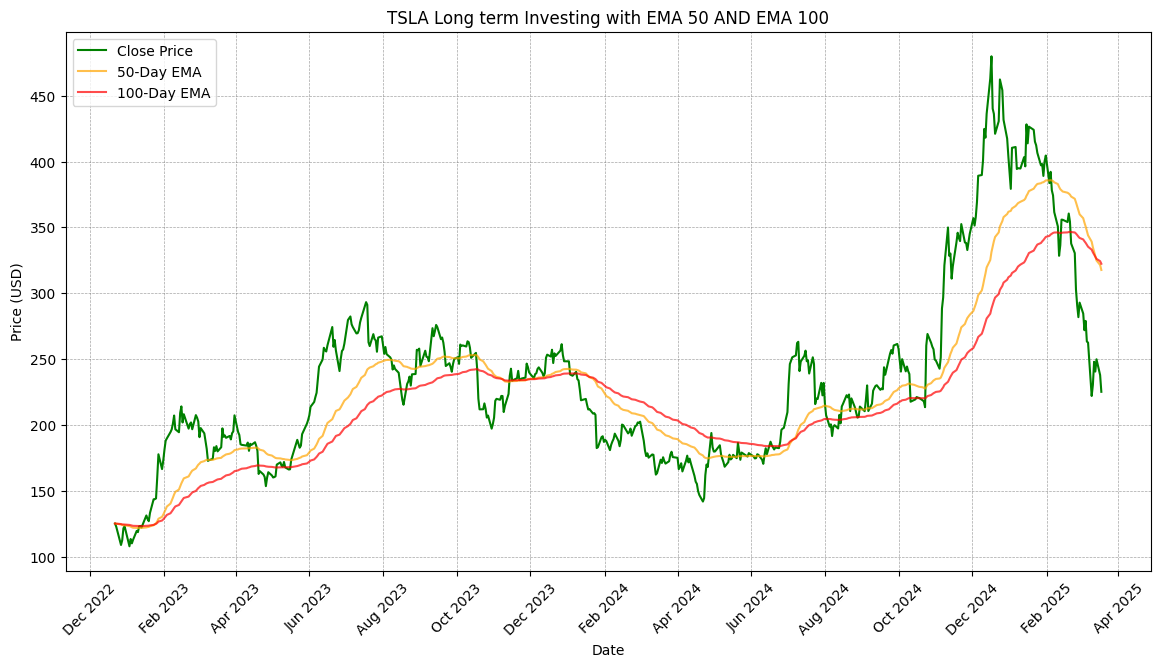

In [10]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(EMA_50, label='50-Day EMA', color='orange', alpha=0.7)
plt.plot(EMA_100, label='100-Day EMA', color='r', alpha=0.7)

plt.title(f'{stock} Long term Investing with EMA 50 AND EMA 100')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Ticks at the start of each month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format as 'Month Year'


# Adjust tick intervals to decrease grid box size
plt.xticks(ticks=plt.xticks()[0], rotation=45)  # Rotate x-axis labels for readability
plt.locator_params(axis='x', nbins=20)  # Increase x-axis grid density
plt.locator_params(axis='y', nbins=15)  # Increase y-axis grid density
plt.xticks(rotation=45)
plt.show()

In [11]:
# Calculate RSI
delta = data['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data['RSI'] = 100 - (100 / (1 + rs))

In [12]:
data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
data['EMA_50'] = data['Close'].ewm(span=50, adjust=False).mean()

# Define Buy and Sell Signals based on conditions
data['Buy_Signal'] = (data['EMA_20'] > data['EMA_50']) & (data['RSI'] < 40)


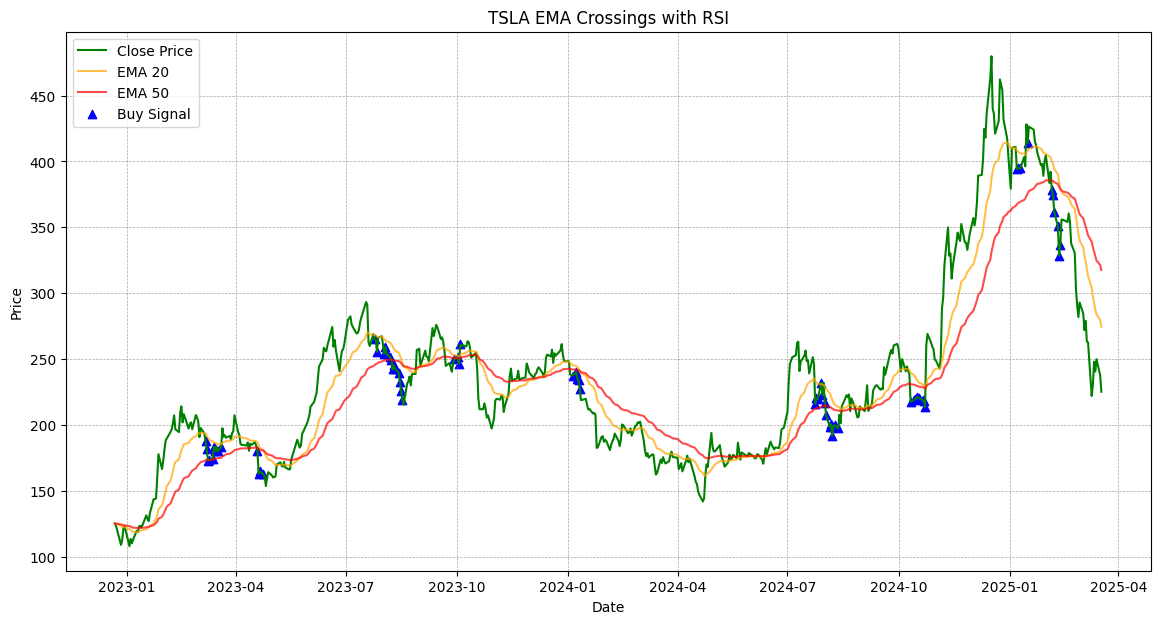

In [13]:
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Close Price', color='g')
plt.plot(data['EMA_20'], label='EMA 20', color='orange', alpha=0.7)
plt.plot(data['EMA_50'], label='EMA 50', color='red', alpha=0.7)

# Add buy and sell signals
plt.scatter(data.index[data['Buy_Signal']], data['Close'][data['Buy_Signal']],
            label='Buy Signal', marker='^', color='blue', alpha=1)


plt.title(f'{stock} EMA Crossings with RSI')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
plt.show()


In [14]:
# Your existing code
data = []
for t in client.vx.list_stock_financials(ticker=selected_stock, filing_date_gte='2025-01-01'):
    data.append(t)

if data:
    # Income Statement
    income_statement = data[0].financials.income_statement
    print("Income Statement:")
    print(f"Revenues: ${income_statement.revenues.value:,.2f}")
    print(f"Cost of Revenue: ${income_statement.cost_of_revenue.value:,.2f}")
    print(f"Gross Profit: ${income_statement.gross_profit.value:,.2f}")
    print(f"Operating Expenses: ${income_statement.operating_expenses.value:,.2f}")
    print(f"Operating Income: ${income_statement.operating_income_loss.value:,.2f}")
    print(f"Net Income: ${income_statement.net_income_loss.value:,.2f}")

    # Balance Sheet
    balance_sheet = data[0].financials.balance_sheet
    print("\nBalance Sheet:")
    print(f"Total Assets: ${balance_sheet.assets.value:,.2f}")
    print(f"Total Liabilities: ${balance_sheet.liabilities.value:,.2f}")
    print(f"Equity: ${balance_sheet.equity.value:,.2f}")

    # Cash Flow Statement
    cash_flow_statement = data[0].financials.cash_flow_statement
    print("\nCash Flow Statement:")
    print(f"Net Cash Flow from Operating Activities: ${cash_flow_statement.net_cash_flow_from_operating_activities.value:,.2f}")
    print(f"Net Cash Flow from Investing Activities: ${cash_flow_statement.net_cash_flow_from_investing_activities.value:,.2f}")
    print(f"Net Cash Flow from Financing Activities: ${cash_flow_statement.net_cash_flow_from_financing_activities.value:,.2f}")
    print(f"Net Cash Flow: ${cash_flow_statement.net_cash_flow.value:,.2f}")

    # Profit Margin
    profit_margin = (income_statement.net_income_loss.value / income_statement.revenues.value) * 100
    print(f"\nProfit Margin: {profit_margin:.2f}%")

    # Current Ratio
    current_ratio = balance_sheet.current_assets.value / balance_sheet.current_liabilities.value
    print(f"Current Ratio: {current_ratio:.2f}")

    # Debt to Equity Ratio
    debt_to_equity = balance_sheet.liabilities.value / balance_sheet.equity.value
    print(f"Debt to Equity Ratio: {debt_to_equity:.2f}")

    # Decision-making logic
    print("\nInvestment Recommendation:")
    if profit_margin > 10 and current_ratio > 1.5 and debt_to_equity < 2:
        print("✅ The company has strong financials and is a good investment.")
    elif profit_margin > 5 and current_ratio > 1 and debt_to_equity < 3:
        print("🟡 The company has moderate financials. Consider further analysis before investing.")
    else:
        print("❌ The company has weak financials. It may not be a safe investment.")
else:
    print("No financial data found for the given ticker and date range.")

Income Statement:
Revenues: $97,690,000,000.00
Cost of Revenue: $80,240,000,000.00
Gross Profit: $17,450,000,000.00
Operating Expenses: $10,374,000,000.00
Operating Income: $7,076,000,000.00
Net Income: $7,153,000,000.00

Balance Sheet:
Total Assets: $122,070,000,000.00
Total Liabilities: $48,390,000,000.00
Equity: $73,617,000,000.00

Cash Flow Statement:
Net Cash Flow from Operating Activities: $14,923,000,000.00
Net Cash Flow from Investing Activities: $-18,787,000,000.00
Net Cash Flow from Financing Activities: $3,853,000,000.00
Net Cash Flow: $-11,000,000.00

Profit Margin: 7.32%
Current Ratio: 2.02
Debt to Equity Ratio: 0.66

Investment Recommendation:
🟡 The company has moderate financials. Consider further analysis before investing.


In [15]:
from datetime import date
import pandas as pd
import yfinance as yf

def get_stock_data(ticker, start="2023-01-01", end=date.today()):
    stock = yf.download(ticker, start=start, end=end)

    # Calculate EMA (if not already in your notebook)
    stock["EMA"] = stock["Close"].ewm(span=20, adjust=False).mean()

    return stock
def calculate_rsi(data, window=14):
    delta = data["Close"].diff(1)
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    data["RSI"] = rsi
    return data

In [16]:
def calculate_fibonacci_levels(data):
    high = data["Close"].max()
    low = data["Close"].min()

    fib_levels = {
        "0%": high,
        "23.6%": high - (0.236 * (high - low)),
        "38.2%": high - (0.382 * (high - low)),
        "50%": high - (0.5 * (high - low)),
        "61.8%": high - (0.618 * (high - low)),
        "100%": low,
    }

    # Convert Series to scalars if needed
    fib_levels = {k: v.item() if isinstance(v, pd.Series) else v for k, v in fib_levels.items()}

    return fib_levels

In [17]:
stock_data = get_stock_data(selected_stock)
stock_data = calculate_rsi(stock_data)
fib_levels = calculate_fibonacci_levels(stock_data)
print(fib_levels)  # Check output

print(stock_data.tail())  # View last few rows to check signals

[*********************100%***********************]  1 of 1 completed

{'0%': 479.8599853515625, '23.6%': 392.1246284484863, '38.2%': 337.8476703643799, '50%': 293.9799919128418, '61.8%': 250.1123134613037, '100%': 108.0999984741211}
Price            Close        High         Low        Open     Volume  \
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA   
Date                                                                    
2025-03-12  248.089996  251.839996  241.100006  247.220001  142215700   
2025-03-13  240.679993  248.289993  232.600006  248.130005  114813500   
2025-03-14  249.979996  251.580002  240.729996  247.309998  100242300   
2025-03-17  238.009995  245.399994  232.800003  245.059998  111900600   
2025-03-18  225.309998  230.100006  222.279999  228.160004  111477600   

Price              EMA        RSI  
Ticker                             
Date                               
2025-03-12  292.642579  22.652673  
2025-03-13  287.693762  23.776866  
2025-03-14  284.101974  28.486726  
2025-03-17  279.712262  31.105280  


[*********************100%***********************]  1 of 1 completed

{'0%': 479.8599853515625, '23.6%': 392.1246284484863, '38.2%': 337.8476703643799, '50%': 293.9799919128418, '61.8%': 250.1123134613037, '100%': 108.0999984741211}


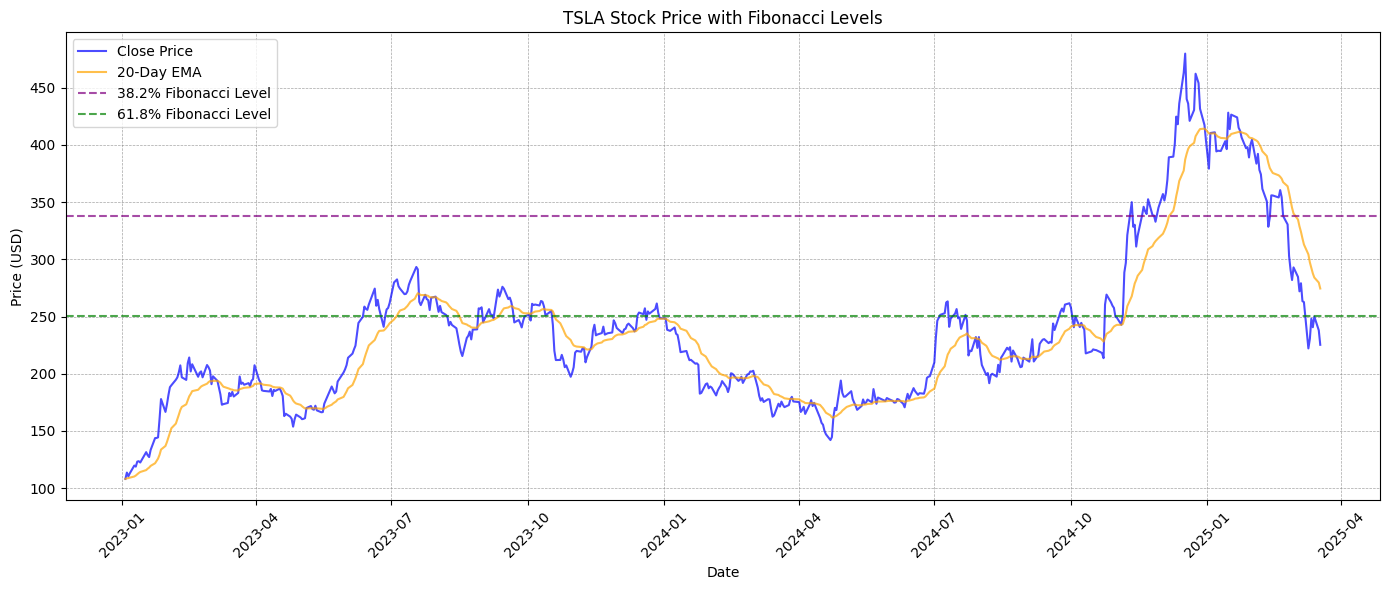

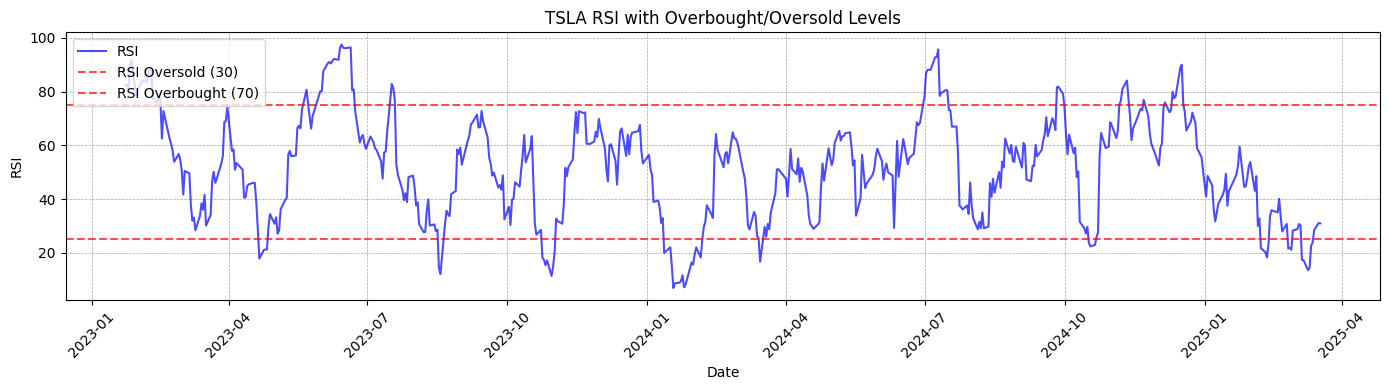

In [18]:
import matplotlib.pyplot as plt

def plot_price_with_fibonacci(data, ema_column="EMA"):
    # Calculate Fibonacci levels
    fib_levels = calculate_fibonacci_levels(data)
    fib_38_2 = fib_levels["38.2%"]
    fib_61_8 = fib_levels["61.8%"]

    # Create a figure and axis
    plt.figure(figsize=(14, 6))

    # Plot the closing price
    plt.plot(data.index, data["Close"], label="Close Price", color="blue", alpha=0.7)

    # Plot the EMA
    plt.plot(data.index, data[ema_column], label="20-Day EMA", color="orange", alpha=0.7)

    # Plot Fibonacci levels
    plt.axhline(y=fib_38_2, color="purple", linestyle="--", label="38.2% Fibonacci Level", alpha=0.7)
    plt.axhline(y=fib_61_8, color="green", linestyle="--", label="61.8% Fibonacci Level", alpha=0.7)

    # Add labels, title, and legend
    plt.title(f"{selected_stock} Stock Price with Fibonacci Levels")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend(loc="upper left")
    plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

def plot_rsi(data, rsi_column="RSI"):
    # Create a figure and axis
    plt.figure(figsize=(14, 4))

    # Plot the RSI
    plt.plot(data.index, data[rsi_column], label="RSI", color="blue", alpha=0.7)

    # Plot RSI levels
    plt.axhline(y=25, color="red", linestyle="--", label="RSI Oversold (30)", alpha=0.7)
    plt.axhline(y=75, color="red", linestyle="--", label="RSI Overbought (70)", alpha=0.7)

    # Add labels, title, and legend
    plt.title(f"{selected_stock} RSI with Overbought/Oversold Levels")
    plt.xlabel("Date")
    plt.ylabel("RSI")
    plt.legend(loc="upper left")
    plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)

    # Show the plot
    plt.tight_layout()
    plt.show()

stock_data = get_stock_data(selected_stock)
stock_data = calculate_rsi(stock_data)
fib_levels = calculate_fibonacci_levels(stock_data)
print(fib_levels)  # Check output

# Plot the price with Fibonacci levels
plot_price_with_fibonacci(stock_data)

# Plot the RSI
plot_rsi(stock_data)